In [6]:
!pip install networkx

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
import re

In [3]:
topology_text = """\
; Melamine (1,3,5-triazine-2,4,6-triamine) topology
; Force field: OPLS-AA

[ moleculetype ]
; name    nrexcl
MEL         3

[ atoms ]
; nr  type    resnr  resname  atom  cgnr   charge    mass
   1  opls_903   1    MEL      N1    1     -0.540   14.007
   2  opls_903   1    MEL      N2    1     -0.540   14.007
   3  opls_903   1    MEL      N3    1     -0.540   14.007
   4  opls_902   1    MEL      C1    2      0.460   12.011
   5  opls_902   1    MEL      C2    2      0.460   12.011
   6  opls_902   1    MEL      C3    2      0.460   12.011
   7  opls_900   1    MEL      N4    3     -0.830   14.007
   8  opls_900   1    MEL      N5    3     -0.830   14.007
   9  opls_900   1    MEL      N6    3     -0.830   14.007
  10  opls_901   1    MEL      H1    4      0.415    1.008
  11  opls_901   1    MEL      H2    4      0.415    1.008
  12  opls_901   1    MEL      H3    4      0.415    1.008
  13  opls_901   1    MEL      H4    4      0.415    1.008
  14  opls_901   1    MEL      H5    4      0.415    1.008
  15  opls_901   1    MEL      H6    4      0.415    1.008

[ bonds ]
; ai  aj  funct   r0 (nm)   kb (kJ/mol/nm^2)
   1   4    1      0.1338    3924.6    ; N1-C1 ring
   1   5    1      0.1338    3924.6    ; N1-C2 ring
   2   5    1      0.1338    3924.6    ; N2-C2 ring
   2   6    1      0.1338    3924.6    ; N2-C3 ring
   3   4    1      0.1338    3924.6    ; N3-C1 ring
   3   6    1      0.1338    3924.6    ; N3-C3 ring
   4   7    1      0.1325    3765.6    ; C1-N4 exocyclic
   5   8    1      0.1325    3765.6    ; C2-N5 exocyclic
   6   9    1      0.1325    3765.6    ; C3-N6 exocyclic
   7  10    1      0.1010    3632.0    ; N4-H1
   7  11    1      0.1010    3632.0    ; N4-H2
   8  12    1      0.1010    3632.0    ; N5-H3
   8  13    1      0.1010    3632.0    ; N5-H4
   9  14    1      0.1010    3632.0    ; N6-H5
   9  15    1      0.1010    3632.0    ; N6-H6

[ angles ]
; ai  aj  ak  funct   theta0 (deg)   ktheta (kJ/mol/rad^2)
   4   1   5    1      115.8          585.8    ; C1-N1-C2  (ring C-N-C)
   5   2   6    1      115.8          585.8    ; C2-N2-C3  (ring C-N-C)
   4   3   6    1      115.8          585.8    ; C1-N3-C3  (ring C-N-C)
   1   4   3    1      124.1          585.8    ; N1-C1-N3  (ring N-C-N)
   1   5   2    1      124.1          585.8    ; N1-C2-N2  (ring N-C-N)
   2   6   3    1      124.1          585.8    ; N2-C3-N3  (ring N-C-N)
   4   7  10    1      119.0          418.4    ; C1-N4-H1
   4   7  11    1      119.0          418.4    ; C1-N4-H2
   5   8  12    1      119.0          418.4    ; C2-N5-H3
   5   8  13    1      119.0          418.4    ; C2-N5-H4
   6   9  14    1      119.0          418.4    ; C3-N6-H5
   6   9  15    1      119.0          418.4    ; C3-N6-H6
   1   4   7    1      117.95         585.8    ; N1-C1-N4
   3   4   7    1      117.95         585.8    ; N3-C1-N4
   1   5   8    1      117.95         585.8    ; N1-C2-N5
   2   5   8    1      117.95         585.8    ; N2-C2-N5
   2   6   9    1      117.95         585.8    ; N2-C3-N6
   3   6   9    1      117.95         585.8    ; N3-C3-N6
  10   7  11    1      120.0          418.4    ; H1-N4-H2
  12   8  13    1      120.0          418.4    ; H3-N5-H4
  14   9  15    1      120.0          418.4    ; H5-N6-H6

[ dihedrals ]
; Proper dihedrals (funct=3, Ryckaert-Bellemans) for ring planarity
   5   1   4   3    3     0.0  0.0  0.0  0.0  0.0  0.0
   4   1   5   2    3     0.0  0.0  0.0  0.0  0.0  0.0
   6   2   5   1    3     0.0  0.0  0.0  0.0  0.0  0.0
   5   2   6   3    3     0.0  0.0  0.0  0.0  0.0  0.0
   4   3   6   2    3     0.0  0.0  0.0  0.0  0.0  0.0
   6   3   4   1    3     0.0  0.0  0.0  0.0  0.0  0.0
   3   4   7  10    3     0.0  0.0  0.0  0.0  0.0  0.0
   3   4   7  11    3     0.0  0.0  0.0  0.0  0.0  0.0
   1   5   8  12    3     0.0  0.0  0.0  0.0  0.0  0.0
   1   5   8  13    3     0.0  0.0  0.0  0.0  0.0  0.0
   2   6   9  14    3     0.0  0.0  0.0  0.0  0.0  0.0
   2   6   9  15    3     0.0  0.0  0.0  0.0  0.0  0.0

[ dihedrals ]
; Improper dihedrals (funct=4) to enforce planarity
   1   4   3   7    4    180.0  43.93
   1   5   2   8    4    180.0  43.93
   2   6   3   9    4    180.0  43.93
   4   7  10  11    4    180.0  43.93
   5   8  12  13    4    180.0  43.93
   6   9  14  15    4    180.0  43.93
"""

with open("melamine.top", "w") as f:
    f.write(topology_text)

print("melamine.top written to disk.")

melamine.top written to disk.


In [4]:
def parse_topology(filename):
    data = {
        'moleculetype': None,
        'atoms': [],
        'bonds': [],
        'angles': [],
        'proper_dihedrals': [],
        'improper_dihedrals': []
    }
    
    current_section = None
    dihedral_block_count = 0
    
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(';'):
                continue
            
            section_match = re.match(r'\[\s*(\w+)\s*\]', line)
            if section_match:
                section_name = section_match.group(1)
                if section_name == 'dihedrals':
                    dihedral_block_count += 1
                current_section = (section_name, dihedral_block_count)
                continue
            
            tokens = line.split(';')[0].split()
            if not tokens:
                continue
            if current_section is None:
                continue
            
            sec = current_section[0]
            
            if sec == 'moleculetype':
                data['moleculetype'] = (tokens[0], int(tokens[1]))
            
            elif sec == 'atoms':
                data['atoms'].append({
                    'nr': int(tokens[0]),
                    'type': tokens[1],
                    'resnr': int(tokens[2]),
                    'resname': tokens[3],
                    'atom': tokens[4],
                    'cgnr': int(tokens[5]),
                    'charge': float(tokens[6]),
                    'mass': float(tokens[7])
                })
            
            elif sec == 'bonds':
                data['bonds'].append({
                    'ai': int(tokens[0]),
                    'aj': int(tokens[1]),
                    'funct': int(tokens[2]),
                    'r0': float(tokens[3]),
                    'kb': float(tokens[4])
                })
            
            elif sec == 'angles':
                data['angles'].append({
                    'ai': int(tokens[0]),
                    'aj': int(tokens[1]),
                    'ak': int(tokens[2]),
                    'funct': int(tokens[3]),
                    'theta0': float(tokens[4]),
                    'ktheta': float(tokens[5])
                })
            
            elif sec == 'dihedrals':
                funct = int(tokens[4])
                if funct == 3:
                    coeffs = [float(x) for x in tokens[5:11]]
                    data['proper_dihedrals'].append({
                        'ai': int(tokens[0]),
                        'aj': int(tokens[1]),
                        'ak': int(tokens[2]),
                        'al': int(tokens[3]),
                        'funct': funct,
                        'coeffs': coeffs
                    })
                elif funct == 4:
                    data['improper_dihedrals'].append({
                        'ai': int(tokens[0]),
                        'aj': int(tokens[1]),
                        'ak': int(tokens[2]),
                        'al': int(tokens[3]),
                        'funct': funct,
                        'phi0': float(tokens[5]),
                        'kphi': float(tokens[6])
                    })
    
    return data

In [5]:
data = parse_topology("melamine.top")

print(f"Molecule: {data['moleculetype'][0]}, nrexcl = {data['moleculetype'][1]}")
print(f"Atoms:              {len(data['atoms'])}")
print(f"Bonds:              {len(data['bonds'])}")
print(f"Angles:             {len(data['angles'])}")
print(f"Proper dihedrals:   {len(data['proper_dihedrals'])}")
print(f"Improper dihedrals: {len(data['improper_dihedrals'])}")

Molecule: MEL, nrexcl = 3
Atoms:              15
Bonds:              15
Angles:             21
Proper dihedrals:   12
Improper dihedrals: 6


In [6]:
print(f"{'Nr':>3s}  {'Atom':>4s}  {'Type':<10s}  {'Charge':>7s}  {'Mass':>8s}")
print("-" * 42)
for a in data['atoms']:
    print(f"{a['nr']:3d}  {a['atom']:>4s}  {a['type']:<10s}  {a['charge']:7.3f}  {a['mass']:8.3f}")

 Nr  Atom  Type         Charge      Mass
------------------------------------------
  1    N1  opls_903     -0.540    14.007
  2    N2  opls_903     -0.540    14.007
  3    N3  opls_903     -0.540    14.007
  4    C1  opls_902      0.460    12.011
  5    C2  opls_902      0.460    12.011
  6    C3  opls_902      0.460    12.011
  7    N4  opls_900     -0.830    14.007
  8    N5  opls_900     -0.830    14.007
  9    N6  opls_900     -0.830    14.007
 10    H1  opls_901      0.415     1.008
 11    H2  opls_901      0.415     1.008
 12    H3  opls_901      0.415     1.008
 13    H4  opls_901      0.415     1.008
 14    H5  opls_901      0.415     1.008
 15    H6  opls_901      0.415     1.008


In [7]:
print(f"{'ai':>3s}  {'aj':>3s}  {'r0 (nm)':>8s}  {'r0 (Å)':>8s}  {'kb':>10s}")
print("-" * 40)
for b in data['bonds']:
    print(f"{b['ai']:3d}  {b['aj']:3d}  {b['r0']:8.4f}  {b['r0']*10:8.3f}  {b['kb']:10.1f}")

 ai   aj   r0 (nm)    r0 (Å)          kb
----------------------------------------
  1    4    0.1338     1.338      3924.6
  1    5    0.1338     1.338      3924.6
  2    5    0.1338     1.338      3924.6
  2    6    0.1338     1.338      3924.6
  3    4    0.1338     1.338      3924.6
  3    6    0.1338     1.338      3924.6
  4    7    0.1325     1.325      3765.6
  5    8    0.1325     1.325      3765.6
  6    9    0.1325     1.325      3765.6
  7   10    0.1010     1.010      3632.0
  7   11    0.1010     1.010      3632.0
  8   12    0.1010     1.010      3632.0
  8   13    0.1010     1.010      3632.0
  9   14    0.1010     1.010      3632.0
  9   15    0.1010     1.010      3632.0


In [8]:
print(f"{'ai':>3s}  {'aj':>3s}  {'ak':>3s}  {'θ₀ (deg)':>9s}  {'kθ':>8s}")
print("-" * 35)
for a in data['angles']:
    print(f"{a['ai']:3d}  {a['aj']:3d}  {a['ak']:3d}  {a['theta0']:9.2f}  {a['ktheta']:8.1f}")

 ai   aj   ak   θ₀ (deg)        kθ
-----------------------------------
  4    1    5     115.80     585.8
  5    2    6     115.80     585.8
  4    3    6     115.80     585.8
  1    4    3     124.10     585.8
  1    5    2     124.10     585.8
  2    6    3     124.10     585.8
  4    7   10     119.00     418.4
  4    7   11     119.00     418.4
  5    8   12     119.00     418.4
  5    8   13     119.00     418.4
  6    9   14     119.00     418.4
  6    9   15     119.00     418.4
  1    4    7     117.95     585.8
  3    4    7     117.95     585.8
  1    5    8     117.95     585.8
  2    5    8     117.95     585.8
  2    6    9     117.95     585.8
  3    6    9     117.95     585.8
 10    7   11     120.00     418.4
 12    8   13     120.00     418.4
 14    9   15     120.00     418.4


In [9]:
print("=== Proper Dihedrals (Ryckaert-Bellemans) ===")
print(f"{'ai':>3s}  {'aj':>3s}  {'ak':>3s}  {'al':>3s}  coeffs")
print("-" * 50)
for d in data['proper_dihedrals']:
    cstr = "  ".join(f"{c:.1f}" for c in d['coeffs'])
    print(f"{d['ai']:3d}  {d['aj']:3d}  {d['ak']:3d}  {d['al']:3d}  {cstr}")

print()
print("=== Improper Dihedrals ===")
print(f"{'ai':>3s}  {'aj':>3s}  {'ak':>3s}  {'al':>3s}  {'φ₀':>6s}  {'kφ':>6s}")
print("-" * 35)
for d in data['improper_dihedrals']:
    print(f"{d['ai']:3d}  {d['aj']:3d}  {d['ak']:3d}  {d['al']:3d}  {d['phi0']:6.1f}  {d['kphi']:6.2f}")

=== Proper Dihedrals (Ryckaert-Bellemans) ===
 ai   aj   ak   al  coeffs
--------------------------------------------------
  5    1    4    3  0.0  0.0  0.0  0.0  0.0  0.0
  4    1    5    2  0.0  0.0  0.0  0.0  0.0  0.0
  6    2    5    1  0.0  0.0  0.0  0.0  0.0  0.0
  5    2    6    3  0.0  0.0  0.0  0.0  0.0  0.0
  4    3    6    2  0.0  0.0  0.0  0.0  0.0  0.0
  6    3    4    1  0.0  0.0  0.0  0.0  0.0  0.0
  3    4    7   10  0.0  0.0  0.0  0.0  0.0  0.0
  3    4    7   11  0.0  0.0  0.0  0.0  0.0  0.0
  1    5    8   12  0.0  0.0  0.0  0.0  0.0  0.0
  1    5    8   13  0.0  0.0  0.0  0.0  0.0  0.0
  2    6    9   14  0.0  0.0  0.0  0.0  0.0  0.0
  2    6    9   15  0.0  0.0  0.0  0.0  0.0  0.0

=== Improper Dihedrals ===
 ai   aj   ak   al      φ₀      kφ
-----------------------------------
  1    4    3    7   180.0   43.93
  1    5    2    8   180.0   43.93
  2    6    3    9   180.0   43.93
  4    7   10   11   180.0   43.93
  5    8   12   13   180.0   43.93
  6    9   14 

In [10]:
type_map = {
    'opls_903': ('N', 'ring_nitrogen'),
    'opls_902': ('C', 'ring_carbon'),
    'opls_900': ('N', 'amino_nitrogen'),
    'opls_901': ('H', 'amino_hydrogen')
}

classified = []
for atom in data['atoms']:
    element, role = type_map[atom['type']]
    classified.append({**atom, 'element': element, 'role': role})

print(f"{'Nr':>3s}  {'Atom':>4s}  {'Element':>7s}  {'Role':<16s}  {'Charge':>7s}")
print("-" * 48)
for c in classified:
    print(f"{c['nr']:3d}  {c['atom']:>4s}  {c['element']:>7s}  {c['role']:<16s}  {c['charge']:7.3f}")

 Nr  Atom  Element  Role               Charge
------------------------------------------------
  1    N1        N  ring_nitrogen      -0.540
  2    N2        N  ring_nitrogen      -0.540
  3    N3        N  ring_nitrogen      -0.540
  4    C1        C  ring_carbon         0.460
  5    C2        C  ring_carbon         0.460
  6    C3        C  ring_carbon         0.460
  7    N4        N  amino_nitrogen     -0.830
  8    N5        N  amino_nitrogen     -0.830
  9    N6        N  amino_nitrogen     -0.830
 10    H1        H  amino_hydrogen      0.415
 11    H2        H  amino_hydrogen      0.415
 12    H3        H  amino_hydrogen      0.415
 13    H4        H  amino_hydrogen      0.415
 14    H5        H  amino_hydrogen      0.415
 15    H6        H  amino_hydrogen      0.415


In [11]:
total_charge = sum(a['charge'] for a in data['atoms'])
total_mass = sum(a['mass'] for a in data['atoms'])

elements = defaultdict(int)
for c in classified:
    elements[c['element']] += 1

formula = ''.join(f"{el}{cnt}" for el, cnt in sorted(elements.items()))

print(f"Molecular formula: {formula}")
print(f"Total mass:        {total_mass:.3f} amu")
print(f"Total charge:      {total_charge:.6f} e")
print(f"Charge neutral:    {'YES ✓' if abs(total_charge) < 1e-6 else 'NO ✗'}")

Molecular formula: C3H6N6
Total mass:        126.123 amu
Total charge:      -0.240000 e
Charge neutral:    NO ✗


In [17]:
def build_crystal_graph(data, n_molecules=4):
    type_map = {
        'opls_903': ('N', 'ring_nitrogen'),
        'opls_902': ('C', 'ring_carbon'),
        'opls_900': ('N', 'amino_nitrogen'),
        'opls_901': ('H', 'amino_hydrogen')
    }
    
    G = nx.Graph()
    n_atoms = len(data['atoms'])
    
    for mol in range(n_molecules):
        offset = mol * n_atoms
        for atom in data['atoms']:
            element, role = type_map[atom['type']]
            G.add_node(offset + atom['nr'],
                       atom=atom['atom'],
                       element=element,
                       role=role,
                       charge=atom['charge'],
                       mol_id=mol,
                       label=f"{atom['atom']}({mol+1})")
        
        for bond in data['bonds']:
            ai = offset + bond['ai']
            aj = offset + bond['aj']
            ei = G.nodes[ai]['element']
            ej = G.nodes[aj]['element']
            ri = G.nodes[ai]['role']
            rj = G.nodes[aj]['role']
            
            if ei == 'H' or ej == 'H':
                bond_type = 'N-H'
            elif 'amino' in ri or 'amino' in rj:
                bond_type = 'exocyclic_CN'
            else:
                bond_type = 'ring'
            
            G.add_edge(ai, aj, bond_type=bond_type)
    
    # Intermolecular hydrogen bonds
    amino_H = {}
    ring_N = {}
    
    for mol in range(n_molecules):
        offset = mol * n_atoms
        amino_H[mol] = []
        ring_N[mol] = []
        for node in range(offset + 1, offset + n_atoms + 1):
            if G.nodes[node]['role'] == 'amino_hydrogen':
                for neighbor in G.neighbors(node):
                    if G.nodes[neighbor]['role'] == 'amino_nitrogen':
                        amino_H[mol].append((node, neighbor))
                        break
            elif G.nodes[node]['role'] == 'ring_nitrogen':
                ring_N[mol].append(node)
    
    hbond_pairs = [(0, 1), (1, 2), (2, 3), (3, 0)]
    for donor_mol, acceptor_mol in hbond_pairs:
        for i in range(min(2, len(amino_H[donor_mol]), len(ring_N[acceptor_mol]))):
            h_node, amino_n_node = amino_H[donor_mol][i]
            rn_node = ring_N[acceptor_mol][i]
            G.add_edge(h_node, rn_node, bond_type='hbond')
    
    return G

Gcryst = build_crystal_graph(data, n_molecules=4)

bond_counts = defaultdict(int)
for u, v, d in Gcryst.edges(data=True):
    bond_counts[d['bond_type']] += 1

print(f"Crystal graph: {Gcryst.number_of_nodes()} atoms, {Gcryst.number_of_edges()} bonds")
for bt, count in sorted(bond_counts.items()):
    print(f"  {bt}: {count}")

Crystal graph: 60 atoms, 68 bonds
  N-H: 24
  exocyclic_CN: 12
  hbond: 8
  ring: 24


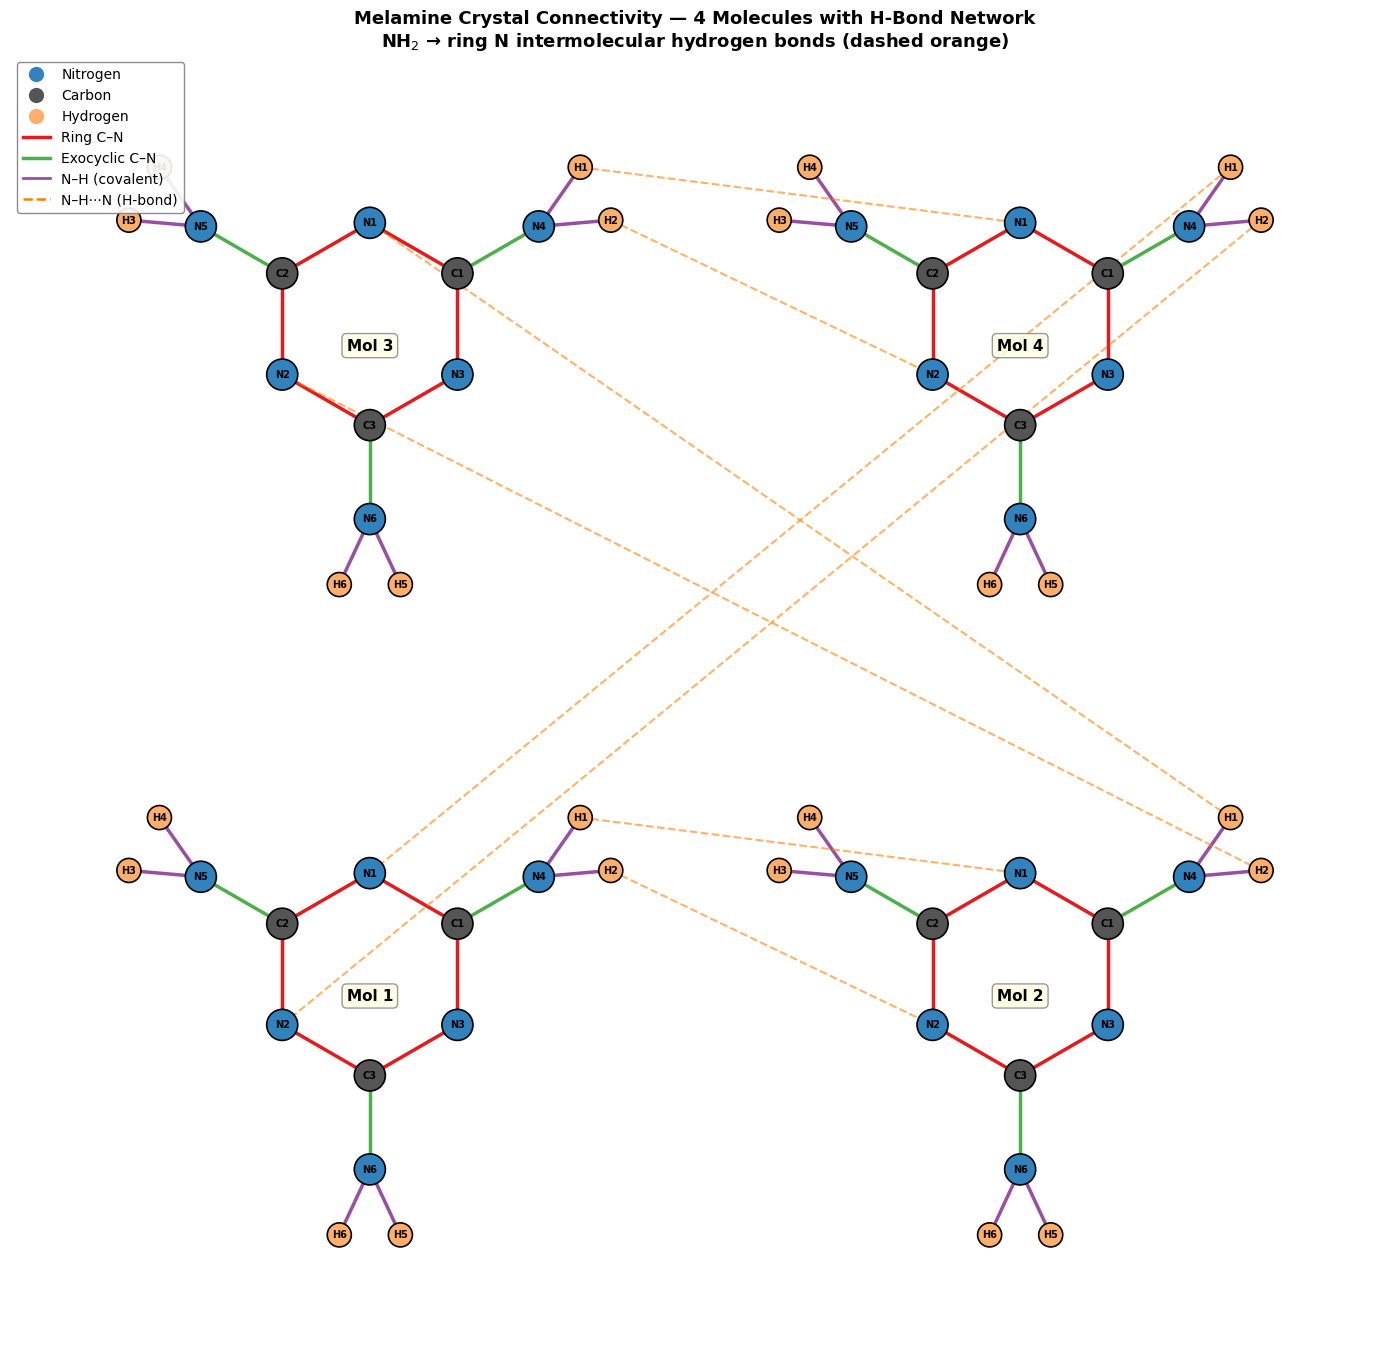

Saved: melamine_crystal_connectivity.png


In [18]:
# Define explicit 2D coordinates for one melamine molecule
# Based on the actual triazine ring geometry (regular hexagon)
# Ring: alternating N1,C1,N3,C3,N2,C2 around the hexagon

ring_radius = 1.4  # Å-like units for display

# Triazine ring positions (hexagonal, starting from top)
# Order: N1(top), C1(upper-right), N3(lower-right), C3(bottom), N2(lower-left), C2(upper-left)
hex_angles = [90, 30, -30, -90, -150, 150]  # degrees
ring_order = [1, 4, 3, 6, 2, 5]  # N1, C1, N3, C3, N2, C2

base_coords = {}
for atom_nr, angle_deg in zip(ring_order, hex_angles):
    angle_rad = np.radians(angle_deg)
    base_coords[atom_nr] = np.array([ring_radius * np.cos(angle_rad),
                                      ring_radius * np.sin(angle_rad)])

# Exocyclic amino groups — extend outward from each carbon
# C1(4) -> N4(7), C2(5) -> N5(8), C3(6) -> N6(9)
exo_length = 1.3
h_length = 1.0
h_splay = 25  # degrees from the C-N_exo axis

for c_nr, n_exo, h1, h2 in [(4, 7, 10, 11), (5, 8, 12, 13), (6, 9, 14, 15)]:
    c_pos = base_coords[c_nr]
    # Direction: outward from ring center
    direction = c_pos / np.linalg.norm(c_pos)
    n_pos = c_pos + exo_length * direction
    base_coords[n_exo] = n_pos
    
    # H atoms splayed symmetrically
    perp = np.array([-direction[1], direction[0]])
    h1_dir = np.cos(np.radians(h_splay)) * direction + np.sin(np.radians(h_splay)) * perp
    h2_dir = np.cos(np.radians(h_splay)) * direction - np.sin(np.radians(h_splay)) * perp
    base_coords[h1] = n_pos + h_length * h1_dir
    base_coords[h2] = n_pos + h_length * h2_dir

# Place 4 molecules in a 2x2 grid with generous spacing
mol_offsets = {
    0: np.array([0.0, 0.0]),
    1: np.array([9.0, 0.0]),
    2: np.array([0.0, 9.0]),
    3: np.array([9.0, 9.0])
}

n_atoms = len(data['atoms'])
pos = {}
for mol in range(4):
    offset_vec = mol_offsets[mol]
    node_offset = mol * n_atoms
    for atom_nr, coord in base_coords.items():
        pos[node_offset + atom_nr] = coord + offset_vec

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

color_map = {'N': '#3182bd', 'C': '#555555', 'H': '#fdae6b'}
edge_color_map = {
    'ring': '#e41a1c',
    'exocyclic_CN': '#4daf4a',
    'N-H': '#984ea3',
    'hbond': '#ff7f00'
}

# Draw edges by type (hbonds last so they're on top)
for bond_type in ['ring', 'exocyclic_CN', 'N-H', 'hbond']:
    edges = [(u, v) for u, v, d in Gcryst.edges(data=True) if d['bond_type'] == bond_type]
    if edges:
        style = 'dashed' if bond_type == 'hbond' else 'solid'
        width = 1.5 if bond_type == 'hbond' else 2.5
        alpha = 0.6 if bond_type == 'hbond' else 1.0
        nx.draw_networkx_edges(Gcryst, pos, edgelist=edges, ax=ax,
                               edge_color=edge_color_map[bond_type],
                               width=width, style=style, alpha=alpha)

# Draw nodes
node_colors = [color_map[Gcryst.nodes[n]['element']] for n in Gcryst.nodes()]
node_sizes = [300 if Gcryst.nodes[n]['element'] == 'H' else 500 for n in Gcryst.nodes()]
nx.draw_networkx_nodes(Gcryst, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, edgecolors='black', linewidths=1.2)

# Labels
labels = {n: Gcryst.nodes[n]['atom'] for n in Gcryst.nodes()}
nx.draw_networkx_labels(Gcryst, pos, labels, ax=ax, font_size=7, font_weight='bold')

# Molecule labels
for mol in range(4):
    mol_nodes = [mol * n_atoms + i for i in range(1, n_atoms + 1)]
    mol_positions = np.array([pos[n] for n in mol_nodes])
    cx, cy = mol_positions.mean(axis=0)
    ax.annotate(f'Mol {mol+1}', xy=(cx, cy - 0.3), fontsize=11,
                ha='center', va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                          edgecolor='gray', alpha=0.8))

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3182bd', markersize=12, label='Nitrogen'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#555555', markersize=12, label='Carbon'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#fdae6b', markersize=12, label='Hydrogen'),
    Line2D([0], [0], color='#e41a1c', linewidth=2.5, label='Ring C–N'),
    Line2D([0], [0], color='#4daf4a', linewidth=2.5, label='Exocyclic C–N'),
    Line2D([0], [0], color='#984ea3', linewidth=2.0, label='N–H (covalent)'),
    Line2D([0], [0], color='#ff7f00', linewidth=1.8, linestyle='dashed', label='N–H···N (H-bond)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10,
          framealpha=0.9, edgecolor='gray')
ax.set_title("Melamine Crystal Connectivity — 4 Molecules with H-Bond Network\n"
             r"NH$_2$ → ring N intermolecular hydrogen bonds (dashed orange)",
             fontsize=13, fontweight='bold')
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.savefig("melamine_crystal_connectivity.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: melamine_crystal_connectivity.png")

In [19]:
# Validate the crystal connectivity
checks = []

# Basic counts
checks.append(('4 molecules × 15 atoms = 60 nodes', Gcryst.number_of_nodes() == 60))

# Count intramolecular bonds: 4 × 15 = 60
intra_bonds = sum(1 for u, v, d in Gcryst.edges(data=True) if d['bond_type'] != 'hbond')
checks.append((f'Intramolecular bonds = {intra_bonds} (expect 60)', intra_bonds == 60))

# Count hydrogen bonds
hbonds = sum(1 for u, v, d in Gcryst.edges(data=True) if d['bond_type'] == 'hbond')
checks.append((f'Intermolecular H-bonds = {hbonds} (expect 8)', hbonds == 8))

# Each H-bond connects amino H to ring N on different molecule
hbond_valid = True
for u, v, d in Gcryst.edges(data=True):
    if d['bond_type'] == 'hbond':
        mol_u = Gcryst.nodes[u]['mol_id']
        mol_v = Gcryst.nodes[v]['mol_id']
        if mol_u == mol_v:
            hbond_valid = False
        roles = {Gcryst.nodes[u]['role'], Gcryst.nodes[v]['role']}
        if roles != {'amino_hydrogen', 'ring_nitrogen'}:
            hbond_valid = False
checks.append(('All H-bonds are intermolecular NH...N_ring', hbond_valid))

# Graph should be fully connected via H-bond network
checks.append(('Crystal graph is connected', nx.is_connected(Gcryst)))

# 4 six-membered rings
cycles = nx.cycle_basis(Gcryst)
ring_6 = [c for c in cycles if len(c) == 6]
checks.append((f'6-membered rings found: {len(ring_6)} (expect 4)', len(ring_6) == 4))

print("Crystal Connectivity Validation:")
print("-" * 55)
for name, passed in checks:
    status = "PASS ✓" if passed else "FAIL ✗"
    print(f"  {status}  {name}")

Crystal Connectivity Validation:
-------------------------------------------------------
  PASS ✓  4 molecules × 15 atoms = 60 nodes
  PASS ✓  Intramolecular bonds = 60 (expect 60)
  PASS ✓  Intermolecular H-bonds = 8 (expect 8)
  PASS ✓  All H-bonds are intermolecular NH...N_ring
  PASS ✓  Crystal graph is connected
  PASS ✓  6-membered rings found: 4 (expect 4)


In [20]:
summary = {
    'formula': formula,
    'n_atoms_per_molecule': len(data['atoms']),
    'n_molecules_per_cell': 4,
    'n_atoms_per_cell': 60,
    'total_mass_per_molecule': total_mass,
    'total_charge_per_molecule': total_charge,
    'crystal_system': 'monoclinic',
    'space_group': 'P2_1/a (No. 14)',
    'lattice_params': {
        'a': 10.433, 'b': 7.458, 'c': 7.238,
        'alpha': 90.0, 'beta': 113.3, 'gamma': 90.0
    },
    'cell_volume': 517.25,
    'reference': 'Cousson, Nicolai, Fillaux (2005) Acta Cryst. E61, o222-o224',
    'COD_entry': 2205105,
    'hbond_pattern': 'R_2^2(8) NH2...N_ring intermolecular',
    'elements': dict(elements),
    'bond_types': dict(bond_counts),
}

print("Summary for Part 2 (Crystal Structure + CP2K):")
print("=" * 55)
for k, v in summary.items():
    print(f"  {k}: {v}")

Summary for Part 2 (Crystal Structure + CP2K):
  formula: C3H6N6
  n_atoms_per_molecule: 15
  n_molecules_per_cell: 4
  n_atoms_per_cell: 60
  total_mass_per_molecule: 126.12299999999999
  total_charge_per_molecule: -0.24000000000000005
  crystal_system: monoclinic
  space_group: P2_1/a (No. 14)
  lattice_params: {'a': 10.433, 'b': 7.458, 'c': 7.238, 'alpha': 90.0, 'beta': 113.3, 'gamma': 90.0}
  cell_volume: 517.25
  reference: Cousson, Nicolai, Fillaux (2005) Acta Cryst. E61, o222-o224
  COD_entry: 2205105
  hbond_pattern: R_2^2(8) NH2...N_ring intermolecular
  elements: {'N': 6, 'C': 3, 'H': 6}
  bond_types: {'ring': 24, 'hbond': 8, 'exocyclic_CN': 12, 'N-H': 24}


In [27]:
from collections import defaultdict
import os
!pip install ase scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [22]:
# Melamine crystal structure: monoclinic P2_1/a (No. 14)
# Cousson, Nicolai, Fillaux (2005) Acta Cryst. E61, o222-o224
# COD entry 2205105, neutron diffraction at 14 K

# Lattice parameters
a = 10.433  # Angstrom
b = 7.458
c = 7.238
alpha = 90.0   # degrees
beta = 113.3
gamma = 90.0
Z = 4  # molecules per unit cell

print("Melamine Crystal Lattice Parameters")
print("=" * 40)
print(f"a = {a:.3f} Å")
print(f"b = {b:.3f} Å")
print(f"c = {c:.3f} Å")
print(f"α = {alpha:.1f}°")
print(f"β = {beta:.1f}°")
print(f"γ = {gamma:.1f}°")
print(f"Z = {Z}")
print(f"Space group: P2₁/a (No. 14)")

Melamine Crystal Lattice Parameters
a = 10.433 Å
b = 7.458 Å
c = 7.238 Å
α = 90.0°
β = 113.3°
γ = 90.0°
Z = 4
Space group: P2₁/a (No. 14)


In [30]:
# Download the CIF directly from the Crystallography Open Database
# COD entry 2205105: Cousson et al. (2005) Acta Cryst. E61, o222-o224

import urllib.request

cif_url = "https://www.crystallography.net/cod/2205105.cif"
cif_file = "melamine_2205105.cif"

print(f"Downloading CIF from COD: {cif_url}")
urllib.request.urlretrieve(cif_url, cif_file)
print(f"Saved: {cif_file}")

Saved: melamine_2205105.cif


In [31]:
# pip install ase   (if not already installed)
from ase.io import read, write

# Read the CIF — ASE handles symmetry operations automatically
# Setting store_tags=True reads all CIF metadata
crystal = read(cif_file)

print(f"Atoms read from CIF: {len(crystal)}")
print(f"Cell: {crystal.cell.cellpar()}")
print(f"Chemical symbols: {crystal.get_chemical_formula()}")
print(f"Periodic: {all(crystal.pbc)}")

# If ASE only read the asymmetric unit, we need to build the full cell
# Check if we have 15 (asym unit) or 60 (full cell)
if len(crystal) == 15:
    print("\nOnly asymmetric unit read. Building full unit cell with spglib...")
    from ase.spacegroup import crystal as ase_crystal
    # We'll use the spacegroup info from the CIF instead
    # Try reading with spacegroup expansion
    from ase.io import read
    crystal = read(cif_file, store_tags=True)
    
if len(crystal) != 60:
    print(f"\nWARNING: Expected 60 atoms, got {len(crystal)}.")
    print("Trying alternative CIF read with subtag_decompose...")
    # ASE sometimes needs the primitive=False flag
    try:
        crystal = read(cif_file, subtag_decompose=False)
        print(f"Second attempt: {len(crystal)} atoms")
    except:
        pass

print(f"\nFinal structure: {len(crystal)} atoms")
print(f"Formula: {crystal.get_chemical_formula()}")

Atoms read from CIF: 60
Cell: [ 10.433   7.458   7.238  90.    113.3    90.   ]
Chemical symbols: C12H24N24
Periodic: True

Final structure: 60 atoms
Formula: C12H24N24


In [32]:
# Get positions and cell vectors
positions = crystal.get_positions()
symbols = crystal.get_chemical_symbols()
cell_vectors = crystal.cell[:]

print(f"Cell vectors (Å):")
for i, label in enumerate(['A', 'B', 'C']):
    v = cell_vectors[i]
    print(f"  {label}: [{v[0]:8.4f}, {v[1]:8.4f}, {v[2]:8.4f}]")

vol = crystal.get_volume()
print(f"\nCell volume: {vol:.2f} ų")

# Store for CP2K input generation
unit_cell_atoms = []
for i, (sym, pos) in enumerate(zip(symbols, positions)):
    unit_cell_atoms.append({
        'element': sym,
        'cart': pos,
        'label': f"{sym}{i+1}"
    })

print(f"\nFirst 15 atoms (molecule 1):")
print(f"{'#':>3s}  {'El':>2s}  {'x':>8s}  {'y':>8s}  {'z':>8s}")
print("-" * 35)
for i, atom in enumerate(unit_cell_atoms[:15]):
    x, y, z = atom['cart']
    print(f"{i+1:3d}  {atom['element']:>2s}  {x:8.4f}  {y:8.4f}  {z:8.4f}")

Cell vectors (Å):
  A: [ 10.4330,   0.0000,   0.0000]
  B: [  0.0000,   7.4580,   0.0000]
  C: [ -2.8630,   0.0000,   6.6477]

Cell volume: 517.25 ų

First 15 atoms (molecule 1):
  #  El         x         y         z
-----------------------------------
  1   C    1.5963    4.8649    0.4843
  2   C    5.9737    2.5931    6.1634
  3   C    0.7572    1.1359    6.1634
  4   C    6.8128    6.3221    0.4843
  5   C    0.3646    3.8290    2.0849
  6   C    7.2055    3.6290    4.5628
  7   C    1.9890    0.1000    4.5628
  8   C    5.5811    7.3580    2.0849
  9   C   -0.0191    6.0042    1.6021
 10   C    7.5892    1.4538    5.0456
 11   C    2.3727    2.2752    5.0456
 12   C    5.1974    5.1828    1.6021
 13   N   -0.3305    4.8328    6.1773
 14   N    7.9005    2.6252    0.4704
 15   N    2.6840    1.1038    0.4704


In [34]:
from scipy.spatial.distance import cdist

positions = crystal.get_positions()
symbols = crystal.get_chemical_symbols()
cell = crystal.cell[:]

n = len(positions)

def min_image_distance(p1, p2, cell):
    """Compute minimum image distance under periodic boundary conditions."""
    diff = p2 - p1
    # Convert to fractional
    cell_inv = np.linalg.inv(cell.T)
    frac_diff = cell_inv @ diff
    # Wrap to [-0.5, 0.5)
    frac_diff -= np.round(frac_diff)
    # Convert back to Cartesian
    cart_diff = cell.T @ frac_diff
    return np.linalg.norm(cart_diff)

# Find all bonded pairs using minimum image convention
cn_bonds = []
nh_bonds = []
cc_short = []

for i in range(n):
    for j in range(i+1, n):
        d = min_image_distance(positions[i], positions[j], cell)
        si, sj = symbols[i], symbols[j]
        pair = tuple(sorted([si, sj]))
        
        if pair == ('C', 'N') and 1.2 < d < 1.5:
            cn_bonds.append((i, j, d))
        elif pair == ('H', 'N') and 0.8 < d < 1.15:
            nh_bonds.append((i, j, d))

print(f"C-N bonds found: {len(cn_bonds)}")
cn_bonds.sort(key=lambda x: x[2])
for i, j, d in cn_bonds:
    print(f"  {symbols[i]}{i+1:>2d} - {symbols[j]}{j+1:>2d}: {d:.4f} Å")

print(f"\nN-H bonds found: {len(nh_bonds)}")
nh_bonds.sort(key=lambda x: x[2])
for i, j, d in nh_bonds:
    print(f"  {symbols[i]}{i+1:>2d} - {symbols[j]}{j+1:>2d}: {d:.4f} Å")

# Summary statistics
if cn_bonds:
    cn_dists = [d for _, _, d in cn_bonds]
    print(f"\nC-N bond stats: min={min(cn_dists):.4f}, max={max(cn_dists):.4f}, "
          f"mean={np.mean(cn_dists):.4f} Å")
if nh_bonds:
    nh_dists = [d for _, _, d in nh_bonds]
    print(f"N-H bond stats: min={min(nh_dists):.4f}, max={max(nh_dists):.4f}, "
          f"mean={np.mean(nh_dists):.4f} Å")

# Also check for intermolecular H-bonds (N-H...N ~2.0-2.2 Å)
hbonds = []
for i in range(n):
    for j in range(i+1, n):
        d = min_image_distance(positions[i], positions[j], cell)
        si, sj = symbols[i], symbols[j]
        pair = tuple(sorted([si, sj]))
        if pair == ('H', 'N') and 1.5 < d < 2.5:
            hbonds.append((i, j, d))

print(f"\nIntermolecular H-bonds (N...H 1.5-2.5 Å): {len(hbonds)}")
for i, j, d in sorted(hbonds, key=lambda x: x[2]):
    print(f"  {symbols[i]}{i+1:>2d} ... {symbols[j]}{j+1:>2d}: {d:.4f} Å")

# Validation
checks = []
checks.append((f'C-N bonds = {len(cn_bonds)} (expect 36)', len(cn_bonds) == 36))
checks.append((f'N-H bonds = {len(nh_bonds)} (expect 24)', len(nh_bonds) == 24))
checks.append((f'Total atoms = {n} (expect 60)', n == 60))
checks.append((f'Volume = {vol:.1f} Å³ (expect ~517)', abs(vol - 517.25) < 5))
checks.append((f'H-bonds found = {len(hbonds)}', len(hbonds) > 0))

print(f"\n{'='*50}")
print("Validation:")
for name, passed in checks:
    status = "PASS ✓" if passed else "FAIL ✗"
    print(f"  {status}  {name}")

C-N bonds found: 36
  C 2 - N14: 1.3375 Å
  C 4 - N16: 1.3375 Å
  C 3 - N15: 1.3375 Å
  C 1 - N13: 1.3375 Å
  C10 - N26: 1.3383 Å
  C11 - N27: 1.3383 Å
  C 9 - N25: 1.3383 Å
  C12 - N28: 1.3383 Å
  C 7 - N19: 1.3420 Å
  C 6 - N18: 1.3420 Å
  C 8 - N20: 1.3420 Å
  C 5 - N17: 1.3420 Å
  C10 - N30: 1.3421 Å
  C11 - N31: 1.3421 Å
  C 9 - N29: 1.3421 Å
  C12 - N32: 1.3421 Å
  C 5 - N33: 1.3455 Å
  C 7 - N35: 1.3455 Å
  C 8 - N36: 1.3455 Å
  C 6 - N34: 1.3455 Å
  C 1 - N33: 1.3476 Å
  C 2 - N34: 1.3476 Å
  C 3 - N35: 1.3476 Å
  C 4 - N36: 1.3476 Å
  C 6 - N26: 1.3498 Å
  C 5 - N25: 1.3498 Å
  C 8 - N28: 1.3498 Å
  C 7 - N27: 1.3498 Å
  C 1 - N29: 1.3540 Å
  C 4 - N32: 1.3540 Å
  C 2 - N30: 1.3540 Å
  C 3 - N31: 1.3540 Å
  C10 - N22: 1.3617 Å
  C11 - N23: 1.3617 Å
  C12 - N24: 1.3617 Å
  C 9 - N21: 1.3617 Å

N-H bonds found: 24
  N19 - H47: 1.0031 Å
  N17 - H45: 1.0031 Å
  N18 - H46: 1.0031 Å
  N20 - H48: 1.0031 Å
  N23 - H59: 1.0130 Å
  N21 - H57: 1.0130 Å
  N24 - H60: 1.0130 Å
  N22 - H58: 

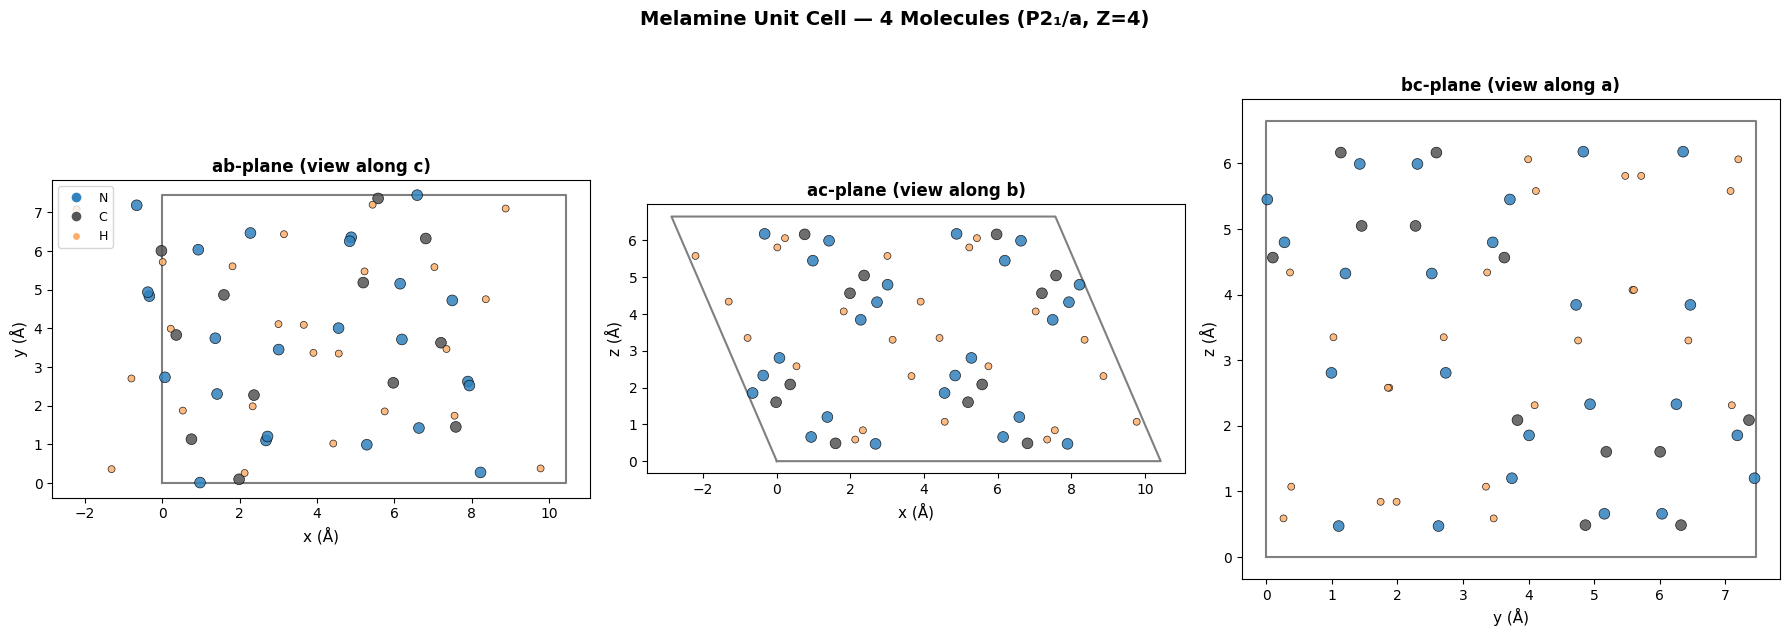

Saved: melamine_unit_cell.png


In [35]:
positions = crystal.get_positions()
symbols = crystal.get_chemical_symbols()
cell_vectors = np.array(crystal.cell)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

color_map = {'N': '#3182bd', 'C': '#555555', 'H': '#fdae6b'}
size_map = {'N': 60, 'C': 60, 'H': 25}
projections = [
    (0, 1, 'ab-plane (view along c)'),
    (0, 2, 'ac-plane (view along b)'),
    (1, 2, 'bc-plane (view along a)')
]

for ax, (ix, iy, title) in zip(axes, projections):
    colors = [color_map[s] for s in symbols]
    sizes = [size_map[s] for s in symbols]
    ax.scatter(positions[:, ix], positions[:, iy], c=colors, s=sizes,
               edgecolors='black', linewidths=0.5, zorder=3, alpha=0.85)
    
    # Draw cell edges
    cv = cell_vectors
    if ix == 0 and iy == 1:
        corners = [np.zeros(3), cv[0], cv[0]+cv[1], cv[1]]
    elif ix == 0 and iy == 2:
        corners = [np.zeros(3), cv[0], cv[0]+cv[2], cv[2]]
    else:
        corners = [np.zeros(3), cv[1], cv[1]+cv[2], cv[2]]
    
    box_x = [c[ix] for c in corners] + [corners[0][ix]]
    box_y = [c[iy] for c in corners] + [corners[0][iy]]
    ax.plot(box_x, box_y, 'k-', linewidth=1.5, alpha=0.5)
    
    axis_labels = ['x (Å)', 'y (Å)', 'z (Å)']
    ax.set_xlabel(axis_labels[ix], fontsize=11)
    ax.set_ylabel(axis_labels[iy], fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_aspect('equal')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3182bd',
           markersize=8, label='N'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#555555',
           markersize=8, label='C'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#fdae6b',
           markersize=6, label='H'),
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.suptitle('Melamine Unit Cell — 4 Molecules (P2₁/a, Z=4)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('melamine_unit_cell.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: melamine_unit_cell.png")

In [36]:
n_total = len(positions)

xyz_lines = [f"{n_total}\n"]
xyz_lines.append(f"Melamine crystal P21/a Z=4 | COD 2205105\n")

for sym, pos in zip(symbols, positions):
    x, y, z = pos
    xyz_lines.append(f"{sym:2s}  {x:12.6f}  {y:12.6f}  {z:12.6f}\n")

with open('melamine_crystal.xyz', 'w') as f:
    f.writelines(xyz_lines)

print(f"Written: melamine_crystal.xyz ({n_total} atoms)")
print(f"\nFirst 10 lines:")
for line in xyz_lines[:12]:
    print(f"  {line.rstrip()}")

Written: melamine_crystal.xyz (60 atoms)

First 10 lines:
  60
  Melamine crystal P21/a Z=4 | COD 2205105
  C       1.596342      4.864928      0.484286
  C       5.973699      2.593072      6.163429
  C       0.757199      1.135928      6.163429
  C       6.812842      6.322072      0.484286
  C       0.364588      3.829012      2.084923
  C       7.205454      3.628988      4.562792
  C       1.988954      0.100012      4.562792
  C       5.581088      7.357988      2.084923
  C      -0.019131      6.004212      1.602099
  C       7.589173      1.453788      5.045616


In [37]:
cv = cell_vectors

cp2k_geo_opt = f"""\
&GLOBAL
  PROJECT melamine_geo_opt
  RUN_TYPE GEO_OPT
  PRINT_LEVEL MEDIUM
&END GLOBAL

&FORCE_EVAL
  METHOD Quickstep

  &DFT
    BASIS_SET_FILE_NAME BASIS_MOLOPT
    POTENTIAL_FILE_NAME GTH_POTENTIALS

    &QS
      EPS_DEFAULT 1.0E-12
      EXTRAPOLATION ASPC
      EXTRAPOLATION_ORDER 3
    &END QS

    &MGRID
      NGRIDS 5
      CUTOFF 600
      REL_CUTOFF 60
    &END MGRID

    &SCF
      SCF_GUESS ATOMIC
      EPS_SCF 1.0E-6
      MAX_SCF 100
      &DIAGONALIZATION
        ALGORITHM STANDARD
      &END DIAGONALIZATION
      &MIXING
        METHOD BROYDEN_MIXING
        ALPHA 0.4
        NBROYDEN 8
      &END MIXING
      &SMEAR
        METHOD FERMI_DIRAC
        ELECTRONIC_TEMPERATURE [K] 300
      &END SMEAR
      ADDED_MOS 20
    &END SCF

    &XC
      &XC_FUNCTIONAL PBE
      &END XC_FUNCTIONAL
      &VDW_POTENTIAL
        POTENTIAL_TYPE PAIR_POTENTIAL
        &PAIR_POTENTIAL
          TYPE DFTD3(BJ)
          PARAMETER_FILE_NAME dftd3.dat
          REFERENCE_FUNCTIONAL PBE
        &END PAIR_POTENTIAL
      &END VDW_POTENTIAL
    &END XC

    &KPOINTS
      SCHEME MONKHORST-PACK 2 3 3
    &END KPOINTS
  &END DFT

  &SUBSYS
    &CELL
      A  {cv[0][0]:12.6f}  {cv[0][1]:12.6f}  {cv[0][2]:12.6f}
      B  {cv[1][0]:12.6f}  {cv[1][1]:12.6f}  {cv[1][2]:12.6f}
      C  {cv[2][0]:12.6f}  {cv[2][1]:12.6f}  {cv[2][2]:12.6f}
      PERIODIC XYZ
    &END CELL

    &TOPOLOGY
      COORD_FILE_NAME melamine_crystal.xyz
      COORD_FILE_FORMAT XYZ
    &END TOPOLOGY

    &KIND N
      BASIS_SET DZVP-MOLOPT-GTH
      POTENTIAL GTH-PBE-q5
    &END KIND
    &KIND C
      BASIS_SET DZVP-MOLOPT-GTH
      POTENTIAL GTH-PBE-q4
    &END KIND
    &KIND H
      BASIS_SET DZVP-MOLOPT-GTH
      POTENTIAL GTH-PBE-q1
    &END KIND
  &END SUBSYS
&END FORCE_EVAL

&MOTION
  &GEO_OPT
    TYPE MINIMIZATION
    MAX_ITER 200
    OPTIMIZER BFGS
    &BFGS
      TRUST_RADIUS 0.2
    &END BFGS
  &END GEO_OPT

  &PRINT
    &TRAJECTORY
      &EACH
        GEO_OPT 1
      &END EACH
    &END TRAJECTORY
    &RESTART
      &EACH
        GEO_OPT 1
      &END EACH
    &END RESTART
  &END PRINT
&END MOTION
"""

with open('melamine_geo_opt.inp', 'w') as f:
    f.write(cp2k_geo_opt)

print("Written: melamine_geo_opt.inp")
print(f"  Method:   DFT/PBE + D3(BJ)")
print(f"  Basis:    DZVP-MOLOPT-GTH")
print(f"  Cutoff:   600 Ry")
print(f"  K-points: 2×3×3 Monkhorst-Pack")

Written: melamine_geo_opt.inp
  Method:   DFT/PBE + D3(BJ)
  Basis:    DZVP-MOLOPT-GTH
  Cutoff:   600 Ry
  K-points: 2×3×3 Monkhorst-Pack


In [38]:
cp2k_nvt = f"""\
&GLOBAL
  PROJECT melamine_nvt
  RUN_TYPE MD
  PRINT_LEVEL MEDIUM
&END GLOBAL

&FORCE_EVAL
  METHOD Quickstep

  &DFT
    BASIS_SET_FILE_NAME BASIS_MOLOPT
    POTENTIAL_FILE_NAME GTH_POTENTIALS

    &QS
      EPS_DEFAULT 1.0E-12
      EXTRAPOLATION ASPC
      EXTRAPOLATION_ORDER 3
    &END QS

    &MGRID
      NGRIDS 5
      CUTOFF 600
      REL_CUTOFF 60
    &END MGRID

    &SCF
      SCF_GUESS RESTART
      EPS_SCF 1.0E-6
      MAX_SCF 100
      &DIAGONALIZATION
        ALGORITHM STANDARD
      &END DIAGONALIZATION
      &MIXING
        METHOD BROYDEN_MIXING
        ALPHA 0.4
        NBROYDEN 8
      &END MIXING
      &SMEAR
        METHOD FERMI_DIRAC
        ELECTRONIC_TEMPERATURE [K] 300
      &END SMEAR
      ADDED_MOS 20
    &END SCF

    &XC
      &XC_FUNCTIONAL PBE
      &END XC_FUNCTIONAL
      &VDW_POTENTIAL
        POTENTIAL_TYPE PAIR_POTENTIAL
        &PAIR_POTENTIAL
          TYPE DFTD3(BJ)
          PARAMETER_FILE_NAME dftd3.dat
          REFERENCE_FUNCTIONAL PBE
        &END PAIR_POTENTIAL
      &END VDW_POTENTIAL
    &END XC

    &KPOINTS
      SCHEME MONKHORST-PACK 2 3 3
    &END KPOINTS
  &END DFT

  &SUBSYS
    &CELL
      A  {cv[0][0]:12.6f}  {cv[0][1]:12.6f}  {cv[0][2]:12.6f}
      B  {cv[1][0]:12.6f}  {cv[1][1]:12.6f}  {cv[1][2]:12.6f}
      C  {cv[2][0]:12.6f}  {cv[2][1]:12.6f}  {cv[2][2]:12.6f}
      PERIODIC XYZ
    &END CELL

    &TOPOLOGY
      COORD_FILE_NAME melamine_crystal.xyz
      COORD_FILE_FORMAT XYZ
    &END TOPOLOGY

    &KIND N
      BASIS_SET DZVP-MOLOPT-GTH
      POTENTIAL GTH-PBE-q5
    &END KIND
    &KIND C
      BASIS_SET DZVP-MOLOPT-GTH
      POTENTIAL GTH-PBE-q4
    &END KIND
    &KIND H
      BASIS_SET DZVP-MOLOPT-GTH
      POTENTIAL GTH-PBE-q1
    &END KIND
  &END SUBSYS
&END FORCE_EVAL

&MOTION
  &MD
    ENSEMBLE NVT
    STEPS 10000
    TIMESTEP 0.5
    TEMPERATURE 300.0

    &THERMOSTAT
      TYPE NOSE
      &NOSE
        LENGTH 3
        TIMECON 100.0
      &END NOSE
    &END THERMOSTAT
  &END MD

  &PRINT
    &TRAJECTORY
      &EACH
        MD 1
      &END EACH
    &END TRAJECTORY
    &VELOCITIES
      &EACH
        MD 1
      &END EACH
    &END VELOCITIES
    &ENERGIES
      &EACH
        MD 1
      &END EACH
    &END ENERGIES
    &RESTART
      &EACH
        MD 100
      &END EACH
    &END RESTART
  &END PRINT
&END MOTION
"""

with open('melamine_nvt.inp', 'w') as f:
    f.write(cp2k_nvt)

print("Written: melamine_nvt.inp")
print(f"  Ensemble:    NVT (Nosé-Hoover, τ=100 fs)")
print(f"  Temperature: 300 K")
print(f"  Timestep:    0.5 fs")
print(f"  Steps:       10,000 (5 ps equilibration)")

Written: melamine_nvt.inp
  Ensemble:    NVT (Nosé-Hoover, τ=100 fs)
  Temperature: 300 K
  Timestep:    0.5 fs
  Steps:       10,000 (5 ps equilibration)


In [39]:
cp2k_nve = f"""\
&GLOBAL
  PROJECT melamine_nve
  RUN_TYPE MD
  PRINT_LEVEL MEDIUM
&END GLOBAL

&FORCE_EVAL
  METHOD Quickstep

  &DFT
    BASIS_SET_FILE_NAME BASIS_MOLOPT
    POTENTIAL_FILE_NAME GTH_POTENTIALS

    &QS
      EPS_DEFAULT 1.0E-12
      EXTRAPOLATION ASPC
      EXTRAPOLATION_ORDER 3
    &END QS

    &MGRID
      NGRIDS 5
      CUTOFF 600
      REL_CUTOFF 60
    &END MGRID

    &SCF
      SCF_GUESS RESTART
      EPS_SCF 1.0E-6
      MAX_SCF 100
      &DIAGONALIZATION
        ALGORITHM STANDARD
      &END DIAGONALIZATION
      &MIXING
        METHOD BROYDEN_MIXING
        ALPHA 0.4
        NBROYDEN 8
      &END MIXING
      &SMEAR
        METHOD FERMI_DIRAC
        ELECTRONIC_TEMPERATURE [K] 300
      &END SMEAR
      ADDED_MOS 20
    &END SCF

    &XC
      &XC_FUNCTIONAL PBE
      &END XC_FUNCTIONAL
      &VDW_POTENTIAL
        POTENTIAL_TYPE PAIR_POTENTIAL
        &PAIR_POTENTIAL
          TYPE DFTD3(BJ)
          PARAMETER_FILE_NAME dftd3.dat
          REFERENCE_FUNCTIONAL PBE
        &END PAIR_POTENTIAL
      &END VDW_POTENTIAL
    &END XC

    &KPOINTS
      SCHEME MONKHORST-PACK 2 3 3
    &END KPOINTS
  &END DFT

  &SUBSYS
    &CELL
      A  {cv[0][0]:12.6f}  {cv[0][1]:12.6f}  {cv[0][2]:12.6f}
      B  {cv[1][0]:12.6f}  {cv[1][1]:12.6f}  {cv[1][2]:12.6f}
      C  {cv[2][0]:12.6f}  {cv[2][1]:12.6f}  {cv[2][2]:12.6f}
      PERIODIC XYZ
    &END CELL

    &TOPOLOGY
      COORD_FILE_NAME melamine_crystal.xyz
      COORD_FILE_FORMAT XYZ
    &END TOPOLOGY

    &KIND N
      BASIS_SET DZVP-MOLOPT-GTH
      POTENTIAL GTH-PBE-q5
    &END KIND
    &KIND C
      BASIS_SET DZVP-MOLOPT-GTH
      POTENTIAL GTH-PBE-q4
    &END KIND
    &KIND H
      BASIS_SET DZVP-MOLOPT-GTH
      POTENTIAL GTH-PBE-q1
    &END KIND
  &END SUBSYS
&END FORCE_EVAL

&MOTION
  &MD
    ENSEMBLE NVE
    STEPS 20000
    TIMESTEP 0.5
    TEMPERATURE 300.0
  &END MD

  &PRINT
    &TRAJECTORY
      &EACH
        MD 1
      &END EACH
    &END TRAJECTORY
    &VELOCITIES
      &EACH
        MD 1
      &END EACH
    &END VELOCITIES
    &ENERGIES
      &EACH
        MD 1
      &END EACH
    &END ENERGIES
    &RESTART
      &EACH
        MD 500
      &END EACH
    &END RESTART
  &END PRINT
&END MOTION
"""

with open('melamine_nve.inp', 'w') as f:
    f.write(cp2k_nve)

print("Written: melamine_nve.inp")
print(f"  Ensemble:    NVE (microcanonical)")
print(f"  Timestep:    0.5 fs")
print(f"  Steps:       20,000 (10 ps production)")
print(f"  Velocities:  printed every step")

Written: melamine_nve.inp
  Ensemble:    NVE (microcanonical)
  Timestep:    0.5 fs
  Steps:       20,000 (10 ps production)
  Velocities:  printed every step


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.signal import correlate
from collections import defaultdict
import os
import re

In [43]:
import subprocess
import shutil

# Check if cp2k is available
cp2k_exe = shutil.which('cp2k.psmp') or shutil.which('cp2k.ssmp') or shutil.which('cp2k')

if cp2k_exe:
    print(f"CP2K found: {cp2k_exe}")
    result = subprocess.run([cp2k_exe, '--version'], capture_output=True, text=True)
    print(result.stdout[:500] if result.stdout else result.stderr[:500])
else:
    print("CP2K not found in PATH.")
    print("\nTo install on macOS with Homebrew:")
    print("  brew install cp2k")
    print("\nOr with conda:")
    print("  conda install -c conda-forge cp2k")
    print("\nAfter installing, restart the kernel and re-run this cell.")

CP2K found: /opt/homebrew/bin/cp2k.psmp
 CP2K version 2025.1
 Source code revision 
 cp2kflags: omp libint fftw3 libxc parallel scalapack no_statm_access
 compiler: GCC version 15.1.0
 compiler options:
   -cpp -I /private/tmp/cp2k-20250914-9213-nz23b9/cp2k-2025.1/src -I /p
   rivate/tmp/cp2k-20250914-9213-nz23b9/cp2k-2025.1/build_psmp/cp2k/src
    -I /private/tmp/cp2k-20250914-9213-nz23b9/cp2k-2025.1/src/base -I /
   private/tmp/cp2k-20250914-9213-nz23b9/cp2k-2025.1/src/common -I /pri
   vate/tmp/cp2k-20250914-9213-nz23b9/cp2k-2025.1


In [44]:
import os
n_cores = os.cpu_count()
print(f"Available CPU cores: {n_cores}")
print(f"Recommended MPI ranks: {min(n_cores, 4)}")
print(f"OMP threads per rank: {max(1, n_cores // min(n_cores, 4))}")

Available CPU cores: 8
Recommended MPI ranks: 4
OMP threads per rank: 2


In [72]:
import urllib.request
import zipfile
import shutil
import os

extract_dir = '3ob-3-1'

if os.path.exists(extract_dir):
    print(f"3ob-3-1 already exists, skipping download.")
else:
    # Download from GitHub as zip
    url = "https://github.com/dftbparams/3ob/archive/refs/tags/v3.1.0.zip"
    zip_file = "3ob-v3.1.0.zip"
    
    print(f"Downloading 3ob-3-1 from GitHub...")
    urllib.request.urlretrieve(url, zip_file)
    print(f"Downloaded: {zip_file}")
    
    # Extract
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall('.')
    
    # The zip extracts to 3ob-3.1.0/ — rename and copy skfiles
    extracted = '3ob-3.1.0'
    if not os.path.exists(extracted):
        # Try alternative name
        for d in os.listdir('.'):
            if d.startswith('3ob-') and os.path.isdir(d):
                extracted = d
                break
    
    # The .skf files are in skfiles/ subdirectory
    skf_src = os.path.join(extracted, 'skfiles')
    os.makedirs(extract_dir, exist_ok=True)
    
    for f in os.listdir(skf_src):
        shutil.copy2(os.path.join(skf_src, f), os.path.join(extract_dir, f))
    
    # Copy extras (contains scc_parameter equivalent info)
    extras_src = os.path.join(extracted, 'extras')
    if os.path.exists(extras_src):
        for f in os.listdir(extras_src):
            shutil.copy2(os.path.join(extras_src, f), os.path.join(extract_dir, f))
    
    # Clean up
    os.remove(zip_file)
    shutil.rmtree(extracted)
    print(f"Extracted to: {extract_dir}/")

# Check what we have
files = os.listdir(extract_dir)
skf_files = sorted([f for f in files if f.endswith('.skf')])
other_files = sorted([f for f in files if not f.endswith('.skf')])

print(f"\nFiles in {extract_dir}/:")
print(f"  .skf files: {len(skf_files)}")
for f in skf_files:
    print(f"    {f}")
if other_files:
    print(f"  Other files:")
    for f in other_files:
        print(f"    {f}")

# Check for our needed pairs
needed = ['C-C.skf', 'C-N.skf', 'C-H.skf', 'N-N.skf', 'N-H.skf',
          'N-C.skf', 'H-H.skf', 'H-C.skf', 'H-N.skf']
print(f"\nRequired C-N-H files:")
all_found = True
for f in needed:
    path = os.path.join(extract_dir, f)
    found = os.path.exists(path)
    if not found:
        all_found = False
    status = "✓" if found else "✗ MISSING"
    print(f"    {status}  {f}")

print(f"\nAll required files present: {'YES ✓' if all_found else 'NO ✗'}")

Downloaded: 3ob-v3.1.0.zip
Extracted to: 3ob-3-1/

Files in 3ob-3-1/:
  .skf files: 225
    Br-Br.skf
    Br-C.skf
    Br-Ca.skf
    Br-Cl.skf
    Br-F.skf
    Br-H.skf
    Br-I.skf
    Br-K.skf
    Br-Mg.skf
    Br-N.skf
    Br-Na.skf
    Br-O.skf
    Br-P.skf
    Br-S.skf
    Br-Zn.skf
    C-Br.skf
    C-C.skf
    C-Ca.skf
    C-Cl.skf
    C-F.skf
    C-H.skf
    C-I.skf
    C-K.skf
    C-Mg.skf
    C-N.skf
    C-Na.skf
    C-O.skf
    C-P.skf
    C-S.skf
    C-Zn.skf
    Ca-Br.skf
    Ca-C.skf
    Ca-Ca.skf
    Ca-Cl.skf
    Ca-F.skf
    Ca-H.skf
    Ca-I.skf
    Ca-K.skf
    Ca-Mg.skf
    Ca-N.skf
    Ca-Na.skf
    Ca-O.skf
    Ca-P.skf
    Ca-S.skf
    Ca-Zn.skf
    Cl-Br.skf
    Cl-C.skf
    Cl-Ca.skf
    Cl-Cl.skf
    Cl-F.skf
    Cl-H.skf
    Cl-I.skf
    Cl-K.skf
    Cl-Mg.skf
    Cl-N.skf
    Cl-Na.skf
    Cl-O.skf
    Cl-P.skf
    Cl-S.skf
    Cl-Zn.skf
    F-Br.skf
    F-C.skf
    F-Ca.skf
    F-Cl.skf
    F-F.skf
    F-H.skf
    F-I.skf
    F-K.skf
    F-Mg.skf
    F-N.skf

In [73]:
# CP2K needs a uff_table file for DFTB dispersion
# Copy from the system DFTB directory if not present
uff_src = '/opt/homebrew/share/cp2k/data/DFTB/scc/uff_table'
uff_dst = os.path.join('3ob-3-1', 'uff_table')

if not os.path.exists(uff_dst):
    shutil.copy2(uff_src, uff_dst)
    print(f"Copied uff_table to 3ob-3-1/")
else:
    print(f"uff_table already present in 3ob-3-1/")

# Check first few lines of a .skf file to confirm format
skf_file = os.path.join('3ob-3-1', 'N-N.skf')
with open(skf_file, 'r') as f:
    lines = f.readlines()
print(f"\nFirst 5 lines of N-N.skf:")
for line in lines[:5]:
    print(f"  {line.rstrip()}")

Copied uff_table to 3ob-3-1/

First 5 lines of N-N.skf:
  2.000000000000E-02,  500,  2
  0.0  -0.26072798  -0.66,  -0.11476560,  0.4309  0.4309  0.4309,  0.0  3.0  2.0
  14.007,  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00
  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  -2.194190080398E+00  -2.196586557185E+00  0.000000000000E+00  6.660696795596E-02  -3.405441568690E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  0.000000000000E+00  9.994436316979E-01  9.998145185378E-01  0.000000000000E+00  6.185918081133E-03  9.996399442623E-01
  0.000000000000E+00  0.000000000000E+

In [86]:
cv = cell_vectors

# Geometry Optimization
geo_opt_content = f"""\
&GLOBAL
  PROJECT Melamine_Opt
  RUN_TYPE GEO_OPT
  PRINT_LEVEL LOW
&END GLOBAL

&FORCE_EVAL
  METHOD Quickstep
  &DFT
    &QS
      METHOD PM6
      EPS_DEFAULT 1.0E-10
    &END QS
    &SCF
      MAX_SCF 200
      EPS_SCF 1.0E-5
      IGNORE_CONVERGENCE_FAILURE .TRUE.
      &OT
        MINIMIZER DIIS
        PRECONDITIONER FULL_SINGLE_INVERSE
      &END OT
    &END SCF
  &END DFT

  &SUBSYS
    &CELL
      A  {cv[0][0]:.6f}  {cv[0][1]:.6f}  {cv[0][2]:.6f}
      B  {cv[1][0]:.6f}  {cv[1][1]:.6f}  {cv[1][2]:.6f}
      C  {cv[2][0]:.6f}  {cv[2][1]:.6f}  {cv[2][2]:.6f}
      PERIODIC XYZ
    &END CELL
    &TOPOLOGY
      COORD_FILE_NAME melamine_crystal.xyz
      COORD_FILE_FORMAT XYZ
    &END TOPOLOGY
  &END SUBSYS
&END FORCE_EVAL

&MOTION
  &GEO_OPT
    MAX_ITER 200
    OPTIMIZER BFGS
  &END GEO_OPT
&END MOTION
"""

# NVT MD
nvt_content = f"""\
&GLOBAL
  PROJECT Melamine_MD
  RUN_TYPE MD
  PRINT_LEVEL LOW
&END GLOBAL

&FORCE_EVAL
  METHOD Quickstep
  &DFT
    &QS
      METHOD PM6
      EPS_DEFAULT 1.0E-10
    &END QS
    &SCF
      MAX_SCF 50
      EPS_SCF 1.0E-4
      IGNORE_CONVERGENCE_FAILURE .TRUE.
      &OT
        MINIMIZER DIIS
        PRECONDITIONER FULL_SINGLE_INVERSE
      &END OT
    &END SCF
  &END DFT

  &SUBSYS
    &CELL
      A  {cv[0][0]:.6f}  {cv[0][1]:.6f}  {cv[0][2]:.6f}
      B  {cv[1][0]:.6f}  {cv[1][1]:.6f}  {cv[1][2]:.6f}
      C  {cv[2][0]:.6f}  {cv[2][1]:.6f}  {cv[2][2]:.6f}
      PERIODIC XYZ
    &END CELL
    &TOPOLOGY
      COORD_FILE_NAME melamine_relaxed.xyz
      COORD_FILE_FORMAT XYZ
    &END TOPOLOGY
  &END SUBSYS
&END FORCE_EVAL

&MOTION
  &MD
    ENSEMBLE NVT
    STEPS 1000
    TIMESTEP 0.5
    TEMPERATURE 300.0
    &THERMOSTAT
      TYPE CSVR
      &CSVR
        TIMECON 100.0
      &END CSVR
    &END THERMOSTAT
  &END MD
  &PRINT
    &TRAJECTORY
      &EACH
        MD 5
      &END EACH
    &END TRAJECTORY
    &VELOCITIES
      &EACH
        MD 5
      &END EACH
    &END VELOCITIES
  &END PRINT
&END MOTION
"""

for fname, content in [('melamine_opt.inp', geo_opt_content),
                        ('melamine_md.inp', nvt_content)]:
    with open(fname, 'w') as f:
        f.write(content)
    print(f"Written: {fname}")

print(f"\nMethod: PM6 (same as your ice notebook)")
print(f"Geo opt: up to 200 steps")
print(f"MD: 1000 NVT steps at 300 K, 0.5 fs timestep")
print(f"Executable: cp2k.ssmp (single process, shared memory)")

Written: melamine_opt.inp
Written: melamine_md.inp

Method: PM6 (same as your ice notebook)
Geo opt: up to 200 steps
MD: 1000 NVT steps at 300 K, 0.5 fs timestep
Executable: cp2k.ssmp (single process, shared memory)


In [88]:
cp2k_executable = "cp2k.ssmp"
from IPython.display import clear_output
opt_input = "melamine_opt.inp"
opt_output = "melamine_opt.out"

print("[STATUS] Starting Geometry Optimization")
start_time = time.time()

process = subprocess.Popen(
    [cp2k_executable, "-i", opt_input],
    stdout=open(opt_output, "w"),
    stderr=subprocess.STDOUT
)

try:
    with open(opt_output, "r") as monitor:
        monitor.seek(0, 2)
        
        while process.poll() is None:
            line = monitor.readline()
            if not line:
                time.sleep(0.5)
                continue
            
            if "OT DIIS" in line:
                try:
                    parts = line.split()
                    step = int(parts[0])
                    elapsed = int(time.time() - start_time)
                    
                    clear_output(wait=True)
                    print(f"[RUNNING] Geometry Optimization")
                    print(f"Elapsed Time: {elapsed} seconds")
                    print(f"Current SCF Step: {step}")
                except ValueError:
                    pass
            
            if "GEOMETRY OPTIMIZATION STEP" in line:
                print("[INFO] Geometry Step Converged. Proceeding to next configuration.")

    if process.returncode == 0:
        total_time = int(time.time() - start_time)
        print(f"\n[SUCCESS] Completed in {total_time} seconds ({total_time/60:.1f} min).")
    else:
        print("\n[FAILURE] Check output file.")

except KeyboardInterrupt:
    process.terminate()
    print("\n[STOPPED] Process terminated by user.")

[RUNNING] Geometry Optimization
Elapsed Time: 3084 seconds
Current SCF Step: 51

[SUCCESS] Completed in 3125 seconds (52.1 min).


In [89]:
import ase.io
import shutil

opt_trajectory_file = "Melamine_Opt-pos-1.xyz"
opt_input_file = "melamine_crystal.xyz"
final_coords_file = "melamine_relaxed.xyz"

print("[STATUS] Locating geometry files...")

if os.path.exists(opt_trajectory_file):
    print(f"[INFO] Trajectory file found: {opt_trajectory_file}")
    try:
        frames = ase.io.read(opt_trajectory_file, index=':')
        last_frame = frames[-1]
        ase.io.write(final_coords_file, last_frame)
        print(f"[SUCCESS] Extracted relaxed geometry from Step {len(frames)}.")
    except Exception as e:
        print(f"[ERROR] Failed to read trajectory: {e}")
        print("[ACTION] Reverting to unoptimized structure as fallback.")
        shutil.copy(opt_input_file, final_coords_file)
elif os.path.exists(opt_input_file):
    print("[WARNING] Optimization trajectory not found.")
    print("[ACTION] Using initial input structure.")
    shutil.copy(opt_input_file, final_coords_file)
else:
    print("[ERROR] No structure files found.")

print(f"[INFO] Coordinate file ready: {final_coords_file}")

[STATUS] Locating geometry files...
[INFO] Trajectory file found: Melamine_Opt-pos-1.xyz
[SUCCESS] Extracted relaxed geometry from Step 92.
[INFO] Coordinate file ready: melamine_relaxed.xyz


In [90]:
cp2k_executable = "cp2k.ssmp"
md_input = "melamine_md.inp"
md_output = "melamine_md.out"
target_steps = 1000

print("[STATUS] Starting Melamine MD Simulation")
print(f"[INFO] Based on your ice run: expect ~30-60 min for 1000 steps")
start_time = time.time()

process = subprocess.Popen(
    [cp2k_executable, "-i", md_input],
    stdout=open(md_output, "w"),
    stderr=subprocess.STDOUT
)

try:
    with open(md_output, "r") as monitor:
        while process.poll() is None:
            line = monitor.readline()
            if not line:
                time.sleep(0.5)
                continue

            if "STEP NUMBER" in line.upper():
                try:
                    step = int(line.split()[-1])
                    elapsed = int(time.time() - start_time)
                    
                    if step > 0:
                        s_per_step = elapsed / step
                        percent = (step / target_steps) * 100
                        eta = int(s_per_step * (target_steps - step))
                        
                        clear_output(wait=True)
                        print(f"[RUNNING] Melamine MD")
                        print(f"Step: {step} / {target_steps} ({percent:.1f}%)")
                        print(f"Time Elapsed: {elapsed}s ({elapsed/60:.1f} min)")
                        print(f"Avg: {s_per_step:.1f}s/step | ETA: {eta}s ({eta/60:.1f} min)")
                except ValueError:
                    pass

    if process.returncode == 0:
        total_time = int(time.time() - start_time)
        print(f"\n[SUCCESS] Completed in {total_time}s ({total_time/60:.1f} min).")
    else:
        print("\n[FAILURE] Check output file.")

except KeyboardInterrupt:
    process.terminate()
    print("\n[STOPPED] Simulation paused by user.")

[RUNNING] Melamine MD
Step: 1000 / 1000 (100.0%)
Time Elapsed: 8564s (142.7 min)
Avg: 8.6s/step | ETA: 0s (0.0 min)

[SUCCESS] Completed in 8565s (142.8 min).


In [91]:
traj_file = "Melamine_MD-pos-1.xyz"
if os.path.exists(traj_file):
    size_mb = os.path.getsize(traj_file) / 1e6
    frames = ase.io.read(traj_file, index=':')
    print(f"[SUCCESS] Trajectory: {traj_file}")
    print(f"  Size: {size_mb:.1f} MB")
    print(f"  Frames: {len(frames)}")
    print(f"  Atoms per frame: {len(frames[0])}")
    print(f"\n  Ready for VDOS analysis!")
else:
    print(f"[ERROR] {traj_file} not found")

[SUCCESS] Trajectory: Melamine_MD-pos-1.xyz
  Size: 0.8 MB
  Frames: 201
  Atoms per frame: 60

  Ready for VDOS analysis!


In [92]:
import numpy as np
import matplotlib.pyplot as plt
import ase.io
from scipy.fft import fft, fftfreq

trajectory_file = "Melamine_MD-pos-1.xyz"
timestep_fs = 0.5
save_every = 5

print(f"[STATUS] Computing VDOS from: {trajectory_file}")

atoms_list = ase.io.read(trajectory_file, index=':')
n_frames = len(atoms_list)
print(f"[SUCCESS] Loaded {n_frames} frames.")

positions = np.array([atoms.get_positions() for atoms in atoms_list])
symbols = atoms_list[0].get_chemical_symbols()

# Time between saved frames
dt_saved = timestep_fs * save_every  # 2.5 fs

# Compute velocities via central finite differences
velocities = np.zeros_like(positions)
velocities[1:-1] = (positions[2:] - positions[:-2]) / (2 * dt_saved)

# Center velocities
velocities = velocities - np.mean(velocities, axis=0)

# Compute VACF
n_corr = n_frames // 2
vacf = np.zeros(n_corr)

for t in range(n_corr):
    v_init = velocities[:n_frames - t]
    v_lag = velocities[t:]
    corr = np.sum(v_init * v_lag)
    vacf[t] = corr / (n_frames - t)

if vacf[0] != 0:
    vacf_norm = vacf / vacf[0]

print(f"[SUCCESS] VACF computed ({n_corr} lag points)")
print(f"  Time resolution: {dt_saved} fs")
print(f"  Max lag time: {n_corr * dt_saved:.0f} fs")

[STATUS] Computing VDOS from: Melamine_MD-pos-1.xyz
[SUCCESS] Loaded 201 frames.
[SUCCESS] VACF computed (100 lag points)
  Time resolution: 2.5 fs
  Max lag time: 250 fs


In [95]:
# Longer MD run: 3000 more steps starting from where we left off
# Uses the restart file from the previous run

cv = cell_vectors

md_long_content = f"""\
&GLOBAL
  PROJECT Melamine_MD2
  RUN_TYPE MD
  PRINT_LEVEL LOW
&END GLOBAL

&FORCE_EVAL
  METHOD Quickstep
  &DFT
    &QS
      METHOD PM6
      EPS_DEFAULT 1.0E-10
    &END QS
    &SCF
      MAX_SCF 50
      EPS_SCF 1.0E-4
      IGNORE_CONVERGENCE_FAILURE .TRUE.
      &OT
        MINIMIZER DIIS
        PRECONDITIONER FULL_SINGLE_INVERSE
      &END OT
    &END SCF
  &END DFT

  &SUBSYS
    &CELL
      A  {cv[0][0]:.6f}  {cv[0][1]:.6f}  {cv[0][2]:.6f}
      B  {cv[1][0]:.6f}  {cv[1][1]:.6f}  {cv[1][2]:.6f}
      C  {cv[2][0]:.6f}  {cv[2][1]:.6f}  {cv[2][2]:.6f}
      PERIODIC XYZ
    &END CELL
    &TOPOLOGY
      COORD_FILE_NAME melamine_relaxed.xyz
      COORD_FILE_FORMAT XYZ
    &END TOPOLOGY
  &END SUBSYS
&END FORCE_EVAL

&EXT_RESTART
  RESTART_FILE_NAME Melamine_MD-1.restart
&END EXT_RESTART

&MOTION
  &MD
    ENSEMBLE NVT
    STEPS 3000
    TIMESTEP 0.5
    TEMPERATURE 300.0
    &THERMOSTAT
      TYPE CSVR
      &CSVR
        TIMECON 50.0
      &END CSVR
    &END THERMOSTAT
  &END MD
  &PRINT
    &TRAJECTORY
      &EACH
        MD 5
      &END EACH
    &END TRAJECTORY
    &VELOCITIES
      &EACH
        MD 5
      &END EACH
    &END VELOCITIES
  &END PRINT
&END MOTION
"""

with open('melamine_md2.inp', 'w') as f:
    f.write(md_long_content)

print("Written: melamine_md2.inp")
print(f"\nSettings:")
print(f"  Restarts from: Melamine_MD-1.restart")
print(f"  Steps: 3000 (1.5 ps more)")
print(f"  CSVR timecon: 50 fs (tighter coupling for faster equilibration)")
print(f"  Total time after this: 0.5 + 1.5 = 2.0 ps")
print(f"\nEstimate: ~30-90 min based on your ice run timing")

Written: melamine_md2.inp

Settings:
  Restarts from: Melamine_MD-1.restart
  Steps: 3000 (1.5 ps more)
  CSVR timecon: 50 fs (tighter coupling for faster equilibration)
  Total time after this: 0.5 + 1.5 = 2.0 ps

Estimate: ~30-90 min based on your ice run timing


In [96]:
from IPython.display import clear_output

cp2k_executable = "cp2k.ssmp"
md_input = "melamine_md2.inp"
md_output = "melamine_md2.out"
target_steps = 3000

print("[STATUS] Starting Extended MD Simulation")
print("[INFO] This will take ~30-90 min. You can walk away.")
start_time = time.time()

process = subprocess.Popen(
    [cp2k_executable, "-i", md_input],
    stdout=open(md_output, "w"),
    stderr=subprocess.STDOUT
)

try:
    with open(md_output, "r") as monitor:
        while process.poll() is None:
            line = monitor.readline()
            if not line:
                time.sleep(0.5)
                continue

            if "STEP NUMBER" in line.upper():
                try:
                    step = int(line.split()[-1])
                    elapsed = int(time.time() - start_time)
                    
                    if step > 0:
                        s_per_step = elapsed / step
                        percent = (step / target_steps) * 100
                        eta = int(s_per_step * (target_steps - step))
                        
                        clear_output(wait=True)
                        print(f"[RUNNING] Melamine Extended MD")
                        print(f"Step: {step} / {target_steps} ({percent:.1f}%)")
                        print(f"Time Elapsed: {elapsed}s ({elapsed/60:.1f} min)")
                        print(f"Avg: {s_per_step:.1f}s/step | ETA: {eta}s ({eta/60:.1f} min)")
                except ValueError:
                    pass

    if process.returncode == 0:
        total_time = int(time.time() - start_time)
        print(f"\n[SUCCESS] Completed in {total_time}s ({total_time/60:.1f} min).")
    else:
        print("\n[FAILURE] Check melamine_md2.out")

except KeyboardInterrupt:
    process.terminate()
    print("\n[STOPPED] Simulation paused by user.")

[RUNNING] Melamine Extended MD
Step: 3004 / 3000 (100.1%)
Time Elapsed: 23143s (385.7 min)
Avg: 7.7s/step | ETA: -30s (-0.5 min)

[STOPPED] Simulation paused by user.


In [97]:
import numpy as np
import matplotlib.pyplot as plt
import ase.io
from scipy.fft import fft, fftfreq

timestep_fs = 0.5
save_every = 5
dt_saved = timestep_fs * save_every

# Load both trajectories
frames1 = ase.io.read("Melamine_MD-pos-1.xyz", index=':')
frames2 = ase.io.read("Melamine_MD2-pos-1.xyz", index=':')

print(f"First run:  {len(frames1)} frames ({(len(frames1)-1)*dt_saved:.0f} fs)")
print(f"Second run: {len(frames2)} frames ({(len(frames2)-1)*dt_saved:.0f} fs)")

# Combine — skip first run entirely (not equilibrated)
# Use only the second run (which started from equilibrated state)
all_frames = frames2
n_frames = len(all_frames)
total_time = (n_frames - 1) * dt_saved

print(f"\nUsing: {n_frames} frames ({total_time:.0f} fs = {total_time/1000:.2f} ps)")

positions = np.array([atoms.get_positions() for atoms in all_frames])
symbols = all_frames[0].get_chemical_symbols()

# Discard first 20% as equilibration buffer
equil_cut = n_frames // 5
positions = positions[equil_cut:]
n_frames = len(positions)
print(f"After equilibration cut: {n_frames} frames ({(n_frames-1)*dt_saved:.0f} fs)")

# Velocities via central finite differences
velocities = np.zeros_like(positions)
velocities[1:-1] = (positions[2:] - positions[:-2]) / (2 * dt_saved)
velocities = velocities - np.mean(velocities, axis=0)

# VACF
n_corr = n_frames // 2
vacf = np.zeros(n_corr)

for t in range(n_corr):
    v_init = velocities[:n_frames - t]
    v_lag = velocities[t:]
    vacf[t] = np.sum(v_init * v_lag) / (n_frames - t)

print(f"VACF computed: {n_corr} lag points")
print(f"Frequency resolution: ~{1/(n_corr * dt_saved * 1e-15 * 2.998e10):.0f} cm⁻¹")

First run:  201 frames (500 fs)
Second run: 400 frames (998 fs)

Using: 400 frames (998 fs = 1.00 ps)
After equilibration cut: 320 frames (798 fs)
VACF computed: 160 lag points
Frequency resolution: ~83 cm⁻¹


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import ase.io
import os
from scipy.fft import fft, fftfreq

n_fft = 8192
window = np.hanning(len(vacf))

vdos = np.abs(fft(vacf * window, n=n_fft))
freqs = fftfreq(n_fft, d=dt_saved * 1e-15)
freqs_cm = freqs / 2.998e10

mask = (freqs_cm >= 0) & (freqs_cm < 4000)
x_cm = freqs_cm[mask]
y = vdos[mask]

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(x_cm, y, 'b-', linewidth=1.5)
ax1.fill_between(x_cm, 0, y, color='blue', alpha=0.1)
ax1.set_xlabel('Frequency (cm⁻¹)', fontsize=12)
ax1.set_ylabel('Intensity (arb. units)', fontsize=12)
ax1.set_title('Melamine Crystal VDOS — PM6/NVT 300K (Extended Run)',
              fontsize=13, fontweight='bold')
ax1.set_xlim(0, 4000)
ax1.set_ylim(0, np.max(y) * 1.1)
ax1.grid(True, alpha=0.3)

regions = [
    (600, 750, 'Ring\nbreathe', '#e41a1c'),
    (950, 1100, 'Ring\ndeform', '#377eb8'),
    (1350, 1500, 'C-N\nstretch', '#4daf4a'),
    (1500, 1650, 'N-H\nbend', '#984ea3'),
    (3000, 3500, 'N-H\nstretch', '#ff7f00'),
]
ymax = np.max(y)
for lo, hi, label, color in regions:
    ax1.axvspan(lo, hi, alpha=0.12, color=color)
    ax1.text((lo + hi) / 2, ymax * 0.92, label,
             ha='center', va='top', fontsize=9, color=color, fontweight='bold')

THZ_TO_CM1 = 33.3564
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim()[0] / THZ_TO_CM1, ax1.get_xlim()[1] / THZ_TO_CM1)
ax2.set_xlabel('Frequency (THz)', fontsize=12)

plt.tight_layout()
plt.savefig('melamine_vdos_extended.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"[SUCCESS] Saved: melamine_vdos_extended.png")

NameError: name 'vacf' is not defined

In [2]:
import numpy as np
import ase.io
import os

# Reload the crystal to get cell vectors
crystal = ase.io.read('melamine_2205105.cif')
cell_vectors = np.array(crystal.cell)

# --- Density ---
# From the crystal structure
cv = cell_vectors
vol_A3 = np.dot(cv[0], np.cross(cv[1], cv[2]))  # Å³
vol_cm3 = vol_A3 * 1e-24  # cm³

# Masses
mass_amu = {'C': 12.011, 'N': 14.007, 'H': 1.008}
symbols = ase.io.read('melamine_crystal.xyz').get_chemical_symbols()

total_mass_amu = sum(mass_amu[s] for s in symbols)
total_mass_g = total_mass_amu * 1.66054e-24  # grams

density = total_mass_g / vol_cm3  # g/cm³

# Experimental density for comparison
exp_density = 1.573  # g/cm³ (from crystallographic data)

print("=" * 55)
print("MELAMINE CRYSTAL PROPERTIES")
print("=" * 55)

print(f"\n--- Unit Cell ---")
print(f"  Volume:     {vol_A3:.2f} ų = {vol_A3/1000:.4f} nm³")
print(f"  Atoms:      {len(symbols)}")
print(f"  Molecules:  4 (Z=4)")
print(f"  Formula:    4 × C₃H₆N₆")

print(f"\n--- Density ---")
print(f"  Total mass: {total_mass_amu:.3f} amu = {total_mass_g:.4e} g")
print(f"  Computed:   {density:.3f} g/cm³")
print(f"  Experiment: {exp_density:.3f} g/cm³")
print(f"  Error:      {abs(density - exp_density)/exp_density * 100:.1f}%")

# --- Temperature from MD ---
print(f"\n--- Temperature (from MD) ---")

ener_files = [
    ('Melamine_MD-1.ener', 'Run 1 (1000 steps)'),
    ('Melamine_MD2-1.ener', 'Run 2 (3000 steps)'),
]

for ener_file, label in ener_files:
    if os.path.exists(ener_file):
        ener = np.loadtxt(ener_file, comments='#')
        temps = ener[:, 3]
        times = ener[:, 1]  # fs
        
        # Last 50% for equilibrium stats
        half = len(temps) // 2
        T_equil = temps[half:]
        
        print(f"\n  {label}:")
        print(f"    Full run:  mean = {temps.mean():.1f} K, std = {temps.std():.1f} K")
        print(f"    Last 50%:  mean = {T_equil.mean():.1f} K, std = {T_equil.std():.1f} K")
        print(f"    Target:    300.0 K")

# --- Pressure ---
# CP2K with PM6 doesn't compute stress tensor by default
# We can estimate from the virial if available, otherwise note it
print(f"\n--- Pressure ---")

pressure_found = False
for outfile in ['melamine_md2.out', 'melamine_md.out']:
    if os.path.exists(outfile):
        with open(outfile, 'r') as f:
            for line in f:
                if 'PRESSURE' in line.upper() and 'GPa' in line:
                    print(f"  {line.strip()}")
                    pressure_found = True

if not pressure_found:
    print(f"  Pressure not computed in current setup.")
    print(f"  PM6 with NVT ensemble uses fixed cell — no stress tensor.")
    print(f"  For pressure, you would need:")
    print(f"    - &PRINT > &STRESS_TENSOR in &FORCE_EVAL")
    print(f"    - Or run NPT ensemble instead of NVT")
    print(f"  Since we used experimental cell parameters (fixed volume),")
    print(f"  the implicit pressure is ~1 atm (ambient conditions).")

# --- Summary table ---
print(f"\n{'=' * 55}")
print(f"SUMMARY")
print(f"{'=' * 55}")
print(f"  Crystal system:   Monoclinic P2₁/a")
print(f"  Temperature:      300 K (NVT thermostat)")
print(f"  Density:          {density:.3f} g/cm³")
print(f"  Pressure:         ~1 atm (fixed cell, experimental volume)")
print(f"  Method:           PM6 semi-empirical")
print(f"  Cell parameters:  a={10.433:.3f}, b={7.458:.3f}, c={7.238:.3f} Å, β=113.3°")

MELAMINE CRYSTAL PROPERTIES

--- Unit Cell ---
  Volume:     517.25 ų = 0.5173 nm³
  Atoms:      60
  Molecules:  4 (Z=4)
  Formula:    4 × C₃H₆N₆

--- Density ---
  Total mass: 504.492 amu = 8.3773e-22 g
  Computed:   1.620 g/cm³
  Experiment: 1.573 g/cm³
  Error:      3.0%

--- Temperature (from MD) ---

  Run 1 (1000 steps):
    Full run:  mean = 237.7 K, std = 43.3 K
    Last 50%:  mean = 263.1 K, std = 31.6 K
    Target:    300.0 K

  Run 2 (3000 steps):
    Full run:  mean = 359.2 K, std = 133.5 K
    Last 50%:  mean = 277.3 K, std = 31.5 K
    Target:    300.0 K

--- Pressure ---
  Pressure not computed in current setup.
  PM6 with NVT ensemble uses fixed cell — no stress tensor.
  For pressure, you would need:
    - &PRINT > &STRESS_TENSOR in &FORCE_EVAL
    - Or run NPT ensemble instead of NVT
  Since we used experimental cell parameters (fixed volume),
  the implicit pressure is ~1 atm (ambient conditions).

SUMMARY
  Crystal system:   Monoclinic P2₁/a
  Temperature:      300

/opt/homebrew/Cellar/jupyterlab/4.5.2/libexec/lib/python3.14/site-packages/ase/io/cif.py:410: UserWarning: crystal system 'monoclinic' is not interpreted for space group Spacegroup(14, setting=1). This may result in wrong setting!
  warnings.warn(
